# Iterative scipy minimize fitting tutorial: MBI filters

This notebook is a lightly annotated version of the MBI scipy-minimize notebooks in `../FLC_0_to_43_degrees/`. It keeps the same fitting flow:

1. read the processed calibration table with `inst.read_csv`,
2. select one MBI wavelength channel,
3. load a previous fit as the starting parameter dictionary `p0`,
4. build a system Mueller matrix,
5. run `scipy.optimize.minimize`,
6. write the updated `p0` to disk, then reuse it on the next iteration.

This tutorial also fits an IMR offset angle as `image_rotator.delta_theta`, following the existing `with_IMR_offset` notebooks. The usual MBI filters are `610`, `670`, `720`, and `760` nm. Inside `instruments.read_csv`, the stored MBI arrays are ordered as `[760, 720, 670, 610]`. This tutorial loops in increasing wavelength order `[610, 670, 720, 760]` and lets `read_csv` choose the right array element.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / "instruments.py").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the cloned vampires_calibration repository.")

sys.path.insert(0, str(REPO_ROOT))
print(f"Using vampires_calibration repo: {REPO_ROOT}")

import instruments as inst
import numpy as np
import pandas as pd
import json

Using vampires_calibration repo: /home/rebeccaz/Github/vampires_calibration


## Input CSV format for MBI

The processed CSV is one row per collapsed calibration image. `inst.read_csv` filters to `OBS-MOD == "IPOL_MBI"` when `obs_mode="MBI"`.

Required columns:

| column | meaning |
| --- | --- |
| `OBS-MOD` | Observation mode. MBI rows are stored as `IPOL_MBI`. |
| `RET-POS1` | HWP angle for that exposure, in degrees. |
| `D_IMRANG` | Image rotator angle, in degrees. |
| `U_FLC` | FLC state label. `A` is mapped to `flc_a_theta`; `B` is mapped to `flc_b_theta`. |
| `diff`, `sum` | Single-difference and single-sum measured values. For MBI these are array-like strings with four channels. |
| `diff_std`, `sum_std` | Uncertainties for `diff` and `sum`, also as four-channel array-like strings for MBI. |

For MBI rows, `diff`, `sum`, `diff_std`, and `sum_std` look like `[19866. 19443. 4891. 349.]`. The code in `read_csv` parses that string, then selects the element associated with the requested `obs_filter`. The hard-coded order is `[760, 720, 670, 610]`.

After filtering, `read_csv` returns:

- `interleaved_values`: `[diff0, sum0, diff1, sum1, ...]`
- `interleaved_stds`: `[diff_std0, sum_std0, diff_std1, sum_std1, ...]`
- `configuration_list`: one dictionary per row, with HWP, image rotator, and FLC angles.

In [2]:
# Data path for the processed 2023-09-14 MBI/IPOL calibration table.
file_path = REPO_ROOT / "data" / "20230914_processed_table.csv"

wavelengths = [
    610,
    670,
    720,
    760,
]
obs_modes = ["MBI"] * len(wavelengths)

# These are the previous fits used as starting points, matching the source MBI notebook.
previous_fits_directory = (
    REPO_ROOT
    / "scipy_minimize"
    / "data_files"
    / "produced"
    / "FLC_0_to_43_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0"
)

# Tutorial outputs go into their own directory so running this notebook does not overwrite
# the existing fit products used by other notebooks.
save_fits_directory = (
    REPO_ROOT
    / "scipy_minimize"
    / "data_files"
    / "produced"
    / "tutorials"
    / "MBI_FLC_0_to_43_ten_percent_retardance_constraints"
)
save_fits_directory.mkdir(parents=True, exist_ok=True)

# Use no EM-gain correction in this tutorial.
em_gains = [1.0] * len(wavelengths)

output_tag = "tutorial_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0_reduced_errors"

assert len(wavelengths) == len(obs_modes) == len(em_gains)

## Quick sanity check: what `read_csv` sees

This preview is not required for fitting, but it is useful when adapting the notebook to a new processed table. The raw rows show the MBI array-valued columns; the parsed arrays show what the optimizer receives for one wavelength.

In [3]:
raw = pd.read_csv(file_path)
preview_columns = [
    "OBS-MOD",
    "FILTER01",
    "RET-POS1",
    "D_IMRANG",
    "U_FLC",
    "diff",
    "diff_std",
    "sum",
    "sum_std",
]

mbi_rows = raw[raw["OBS-MOD"].eq("IPOL_MBI")]
print(f"Raw MBI rows: {len(mbi_rows)}")
print(mbi_rows[preview_columns].head(4).to_string(index=False))

sample_wavelength = wavelengths[0]
interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
    file_path,
    obs_mode="MBI",
    obs_filter=sample_wavelength,
    flc_a_theta=0,
    flc_b_theta=43,
)

print(f"\nParsed wavelength: {sample_wavelength} nm")
print(f"interleaved_values shape: {np.shape(interleaved_values)}")
print(f"interleaved_stds shape: {np.shape(interleaved_stds)}")
print(f"configuration_list length: {len(configuration_list)}")
print("First three parsed configurations:")
for config in configuration_list[:3]:
    print(config)

Raw MBI rows: 160
 OBS-MOD FILTER01  RET-POS1  D_IMRANG U_FLC                                  diff                                                  diff_std                               sum                                               sum_std
IPOL_MBI     Open       0.0      45.0     A         [19866. 19443.  4891.   349.]     [688.95936526 490.84405008 297.56603571 107.26629169] [23740.5 27359.5 12895.5  3826.5] [798.7614491  609.00069175 320.43863258 101.54448365]
IPOL_MBI     Open       0.0      45.0     B [-22265.5 -26523.5  -8596.   -1399. ]     [791.45797182 874.41319752 371.83239858 137.21455296] [22477.5 29186.  13342.5  3712. ] [797.27596033 820.95045601 361.46138687 119.37249339]
IPOL_MBI     Open       0.0      57.5     A     [13337.5 10360.5  1190.5  -369. ]     [531.8586925  430.85857472 245.18839875 101.49982072] [22094.5 27538.5 12976.   3808.5] [800.67495167 661.5367788  343.47489688  97.65599607]
IPOL_MBI     Open       0.0      57.5     B [-15543.5 -17840.5  -5411.

## Starting-fit JSON format

Each fit starts from a JSON file with the same nested component dictionary used by the optimizer. The outer keys are optical components (`dichroic`, `flc`, `optics`, `image_rotator`, `hwp`, and `lp`). The inner keys are the parameters that will be fit.

Conventions used here:

- phase/retardance-like `phi` values are in radians,
- rotation/offset angles such as `theta` and `delta_theta` are in degrees,
- diattenuation terms such as `epsilon` are unitless,
- `wollaston.transmission_ratio` is fixed by `em_gains` and is not included in `p0`; this tutorial sets every value to `1.0`.
- old starting-fit files may not contain `image_rotator.delta_theta`; this tutorial initializes that IMR offset to `0.0` degrees before fitting.

The order of entries in `p0` matters because `inst.parse_configuration(p0)` turns this dictionary into the vector passed to scipy. Keep the `bounds` list in the same order as the parameters in `p0`.

In [ ]:
# NOTE: This .txt file can be changed to have different starting guesses
sample_fit_path = (
    previous_fits_directory
    / f"{wavelengths[0]}nm_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0.txt"
)

with open(sample_fit_path, "r") as f:
    sample_p0 = json.load(f)

print(sample_fit_path)
print(json.dumps(sample_p0, indent=4))

/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/FLC_0_to_43_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0/610nm_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0.txt
{
    "dichroic": {
        "phi": 1.1748622366245378,
        "epsilon": 9.550782891721605e-08,
        "theta": 4.296293002353966
    },
    "flc": {
        "phi": 2.9889311154778575,
        "delta_theta": -4.999887702372607
    },
    "optics": {
        "phi": 1.8168289692991788,
        "epsilon": 0.014511021184725675,
        "theta": -2.6959702646203887
    },
    "image_rotator": {
        "phi": 1.3980192389832444
    },
    "hwp": {
        "phi": 2.8133258403788908,
        "delta_theta": 2.5299204449105863
    },
    "lp": {
        "theta": 2.4406141119020486
    }
}


## Fit each MBI wavelength iteratively

The loop stops when the absolute change in log-likelihood is less than one percent of the previous value.


Fitting MBI wavelength: 610 nm
Initial logl value: 900.9174536967251


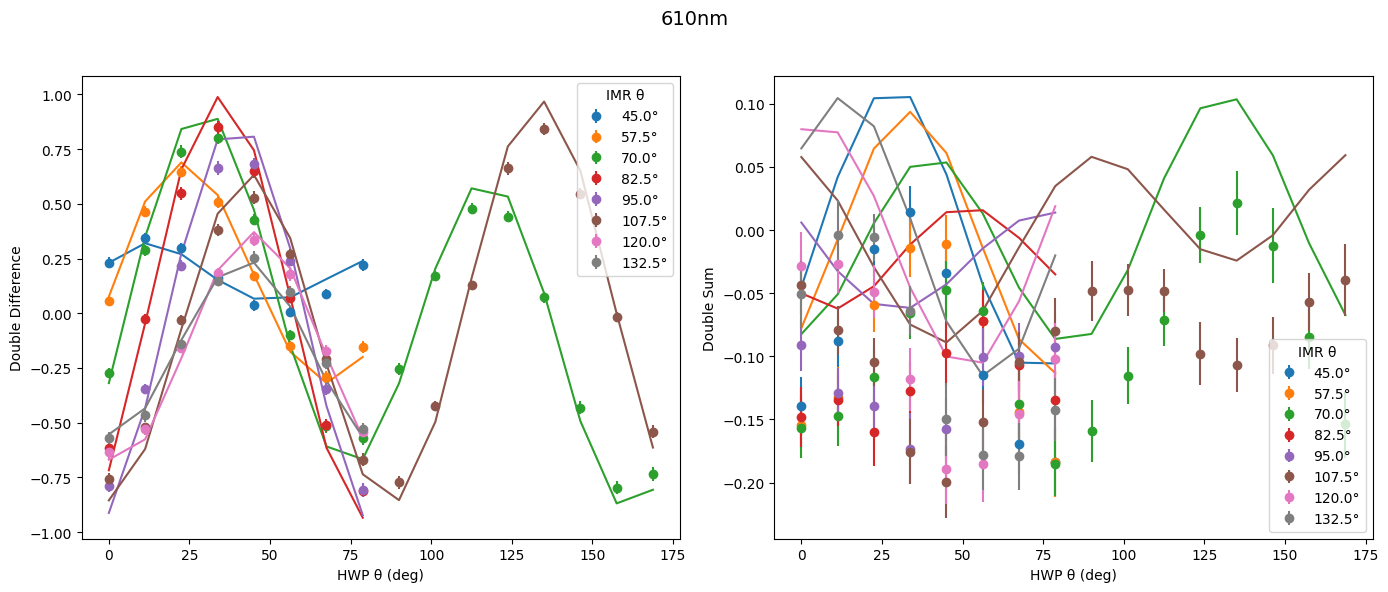

Before p0: {'dichroic': {'phi': 1.1748622366245378, 'epsilon': 9.550782891721605e-08, 'theta': 4.296293002353966}, 'flc': {'phi': 2.9889311154778575, 'delta_theta': -4.999887702372607}, 'optics': {'phi': 1.8168289692991788, 'epsilon': 0.014511021184725675, 'theta': -2.6959702646203887}, 'image_rotator': {'phi': 1.3980192389832444, 'delta_theta': 0.0}, 'hwp': {'phi': 2.8133258403788908, 'delta_theta': 2.5299204449105863}, 'lp': {'theta': 2.4406141119020486}}
Iteration #: 1
logl_value: 889.0798865813287
Best Fit Parameters: [ 1.12950292e+00  1.00550529e-07  3.43196014e+00  3.12244885e+00
 -4.99979938e+00  1.54046241e+00  2.01531189e-02 -1.78184094e+00
  1.38958923e+00  4.51305535e-04  2.79657942e+00  2.35675562e+00
  2.28143098e+00]


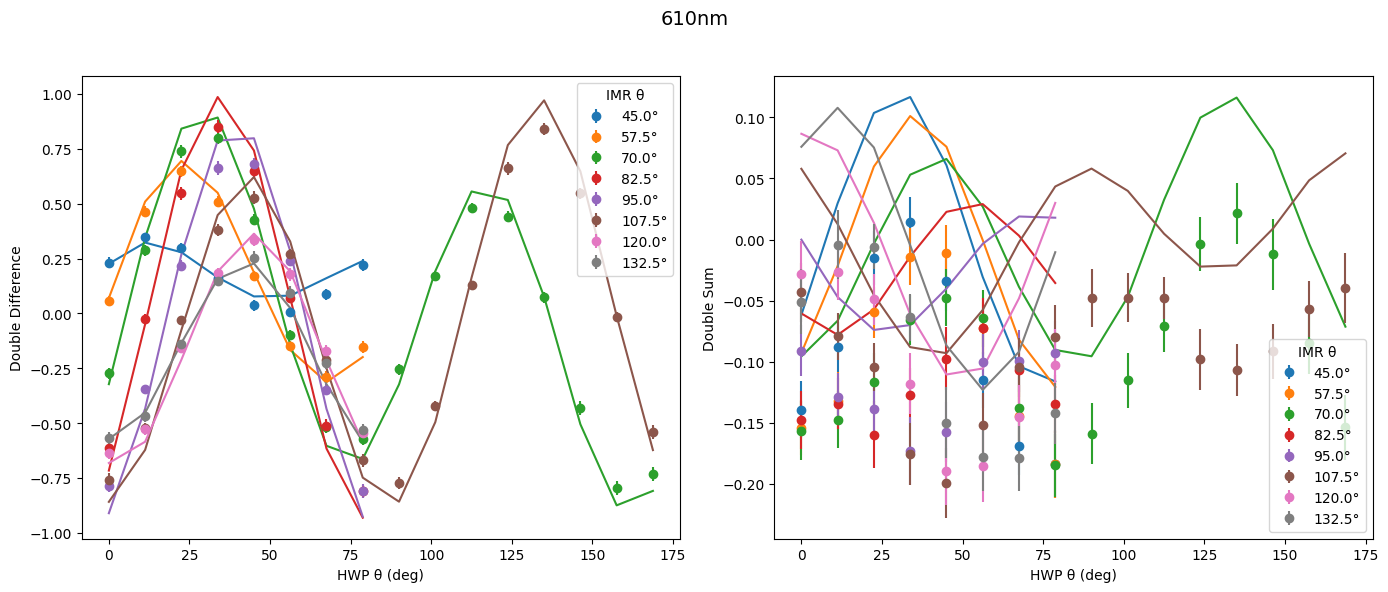

After p0: {'dichroic': {'phi': 1.129502922755607, 'epsilon': 1.0055052897037931e-07, 'theta': 3.4319601422701664}, 'flc': {'phi': 3.1224488505628516, 'delta_theta': -4.999799382510929}, 'optics': {'phi': 1.540462409954264, 'epsilon': 0.02015311887220829, 'theta': -1.7818409431943238}, 'image_rotator': {'phi': 1.3895892307109903, 'delta_theta': 0.00045130553487325305}, 'hwp': {'phi': 2.7965794181882258, 'delta_theta': 2.3567556190860204}, 'lp': {'theta': 2.2814309815864373}}
Before p0: {'dichroic': {'phi': 1.129502922755607, 'epsilon': 1.0055052897037931e-07, 'theta': 3.4319601422701664}, 'flc': {'phi': 3.1224488505628516, 'delta_theta': -4.999799382510929}, 'optics': {'phi': 1.540462409954264, 'epsilon': 0.02015311887220829, 'theta': -1.7818409431943238}, 'image_rotator': {'phi': 1.3895892307109903, 'delta_theta': 0.00045130553487325305}, 'hwp': {'phi': 2.7965794181882258, 'delta_theta': 2.3567556190860204}, 'lp': {'theta': 2.2814309815864373}}
Iteration #: 2
logl_value: 881.6983003886

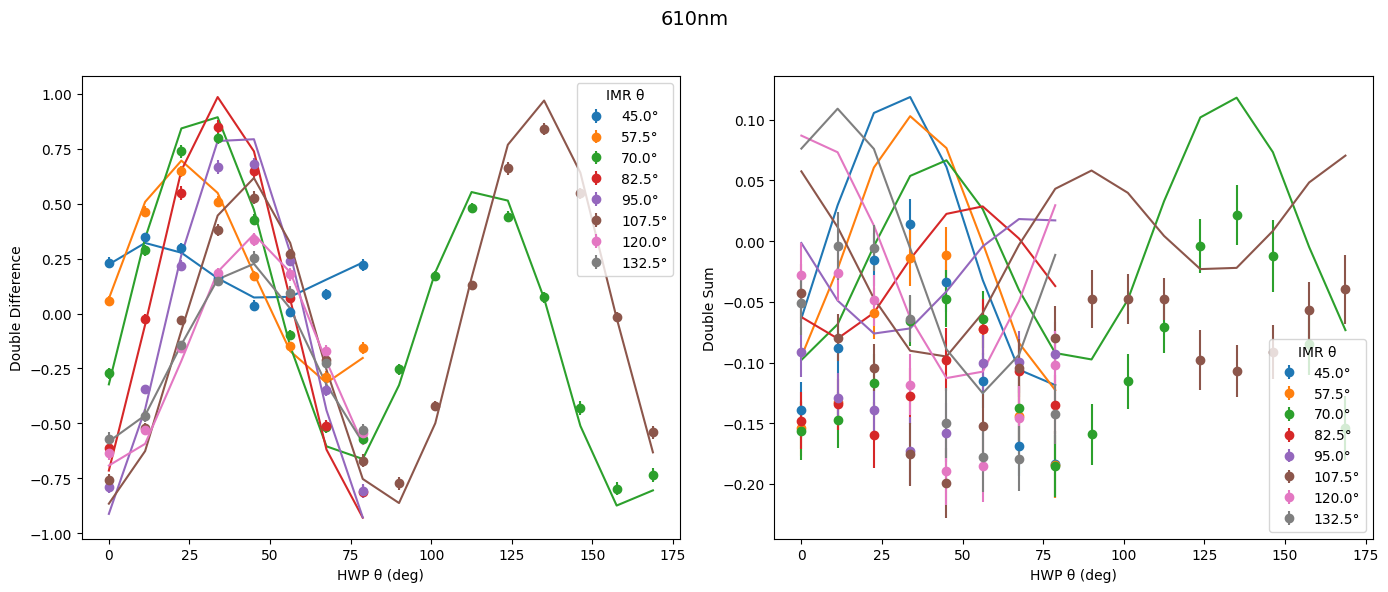

After p0: {'dichroic': {'phi': 2.9265897637316636, 'epsilon': 7.499753668349871e-07, 'theta': 5.380990282291461}, 'flc': {'phi': 3.466097595536053, 'delta_theta': -4.987518430916795}, 'optics': {'phi': 1.6215756256154426, 'epsilon': 0.026178832356476726, 'theta': -9.999742888614106}, 'image_rotator': {'phi': 1.387446825282618, 'delta_theta': 0.0004088721538753216}, 'hwp': {'phi': 2.7963772560780993, 'delta_theta': 2.1883432340128968}, 'lp': {'theta': 1.9163411984352032}}
Before p0: {'dichroic': {'phi': 2.9265897637316636, 'epsilon': 7.499753668349871e-07, 'theta': 5.380990282291461}, 'flc': {'phi': 3.466097595536053, 'delta_theta': -4.987518430916795}, 'optics': {'phi': 1.6215756256154426, 'epsilon': 0.026178832356476726, 'theta': -9.999742888614106}, 'image_rotator': {'phi': 1.387446825282618, 'delta_theta': 0.0004088721538753216}, 'hwp': {'phi': 2.7963772560780993, 'delta_theta': 2.1883432340128968}, 'lp': {'theta': 1.9163411984352032}}
Iteration #: 3
logl_value: 879.0100824982804
Be

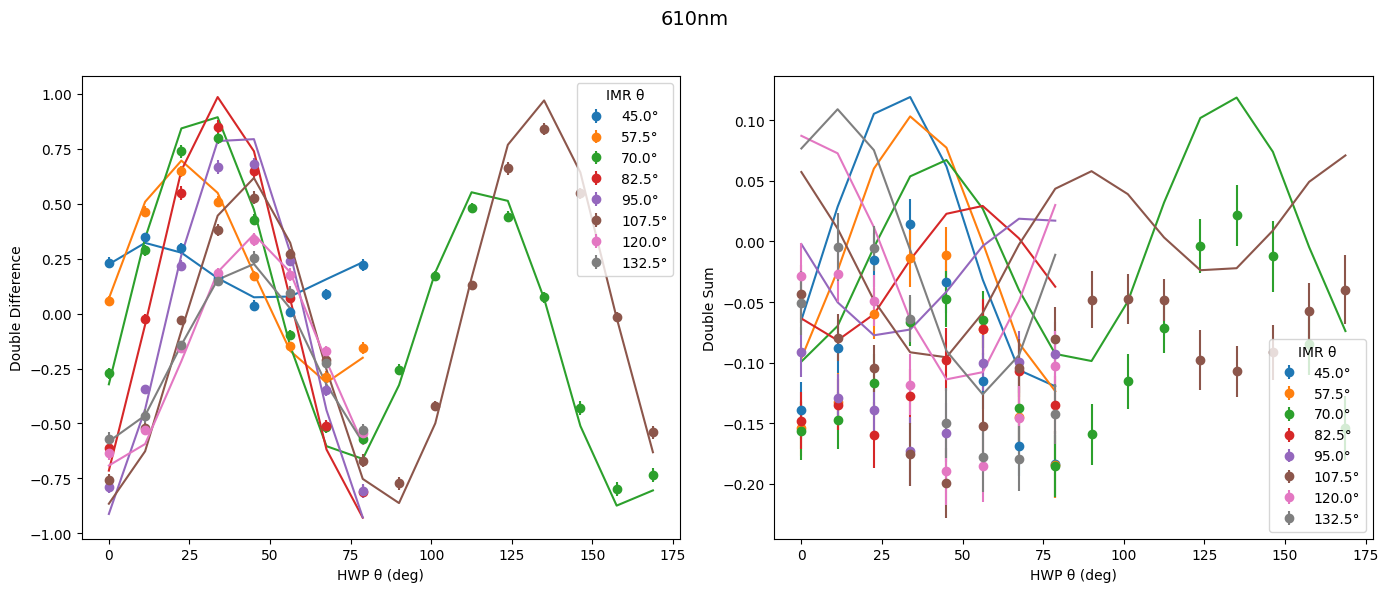

After p0: {'dichroic': {'phi': 2.914300270540533, 'epsilon': 0.0002678891220688034, 'theta': 9.971555800103246}, 'flc': {'phi': 3.4444210154631527, 'delta_theta': -0.08256912777196601}, 'optics': {'phi': 1.6139667878885344, 'epsilon': 0.025675529377194542, 'theta': -9.566964539450968}, 'image_rotator': {'phi': 1.387838021989877, 'delta_theta': -0.03272759413372976}, 'hwp': {'phi': 2.7954024839046987, 'delta_theta': 2.139933363656663}, 'lp': {'theta': 1.8638024059587668}}
Before p0: {'dichroic': {'phi': 2.914300270540533, 'epsilon': 0.0002678891220688034, 'theta': 9.971555800103246}, 'flc': {'phi': 3.4444210154631527, 'delta_theta': -0.08256912777196601}, 'optics': {'phi': 1.6139667878885344, 'epsilon': 0.025675529377194542, 'theta': -9.566964539450968}, 'image_rotator': {'phi': 1.387838021989877, 'delta_theta': -0.03272759413372976}, 'hwp': {'phi': 2.7954024839046987, 'delta_theta': 2.139933363656663}, 'lp': {'theta': 1.8638024059587668}}
Iteration #: 4
logl_value: 299.54251360975593
B

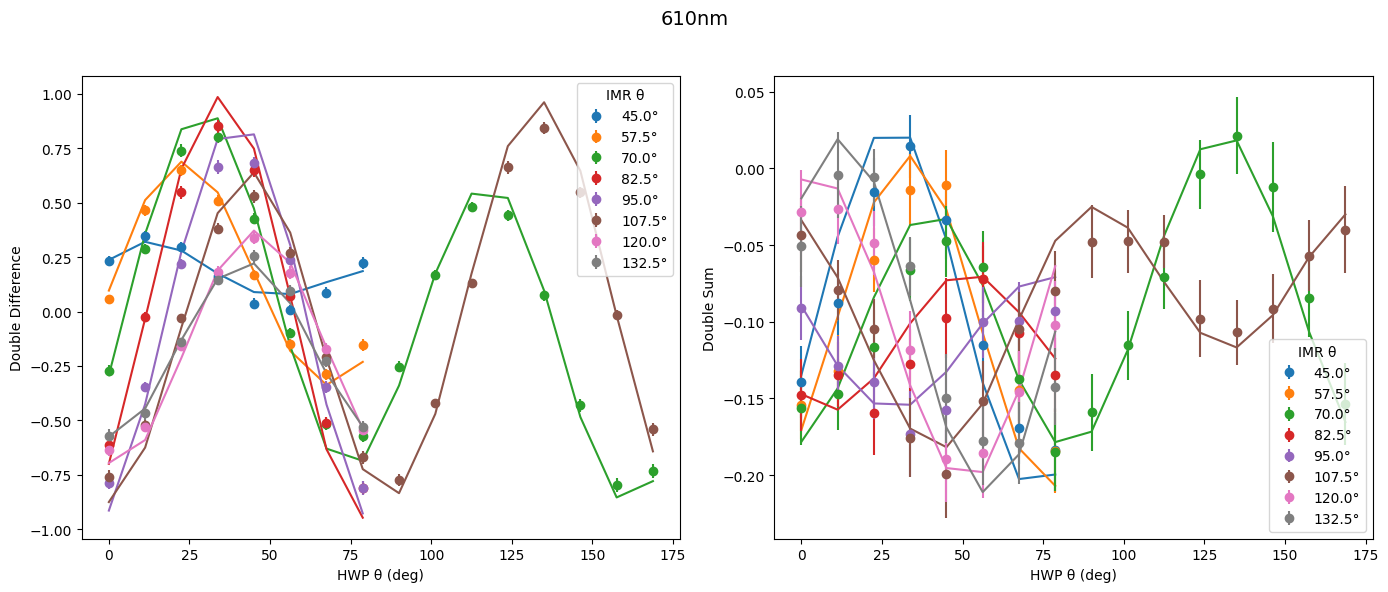

After p0: {'dichroic': {'phi': 2.732379502383738, 'epsilon': 0.0948607156471451, 'theta': 8.815452329685325}, 'flc': {'phi': 2.673450092119758, 'delta_theta': 3.5457173032620837}, 'optics': {'phi': 2.5089495968651816, 'epsilon': 0.01134230320352797, 'theta': -3.6244833929997906}, 'image_rotator': {'phi': 1.39224349920811, 'delta_theta': -0.9497210181205}, 'hwp': {'phi': 2.823424239291958, 'delta_theta': -1.17748866447061}, 'lp': {'theta': -4.961086196665832}}
Before p0: {'dichroic': {'phi': 2.732379502383738, 'epsilon': 0.0948607156471451, 'theta': 8.815452329685325}, 'flc': {'phi': 2.673450092119758, 'delta_theta': 3.5457173032620837}, 'optics': {'phi': 2.5089495968651816, 'epsilon': 0.01134230320352797, 'theta': -3.6244833929997906}, 'image_rotator': {'phi': 1.39224349920811, 'delta_theta': -0.9497210181205}, 'hwp': {'phi': 2.823424239291958, 'delta_theta': -1.17748866447061}, 'lp': {'theta': -4.961086196665832}}


KeyboardInterrupt: 

In [5]:
convergence_fraction = 0.001
max_iterations = 50

for i, wavelength in enumerate(wavelengths):
    print("\n" + "=" * 80)
    print(f"Fitting MBI wavelength: {wavelength} nm")

    interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
        file_path,
        obs_mode=obs_modes[i],
        obs_filter=wavelength,
        flc_a_theta=0,
        flc_b_theta=43, # NOTE: Can change FLC B angle to anything
    )

    filename = previous_fits_directory / f"{wavelength}nm_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0.txt"

    with open(filename, "r") as f:
        past_fit = json.load(f)
    past_fit.setdefault("image_rotator", {})
    past_fit["image_rotator"].setdefault("delta_theta", 0.0)

    theta_pol = past_fit["lp"]["theta"]
    delta_HWP = past_fit["hwp"]["phi"]
    offset_HWP = past_fit["hwp"]["delta_theta"]
    delta_derot = past_fit["image_rotator"]["phi"]
    offset_derot = past_fit["image_rotator"]["delta_theta"]
    delta_opts = past_fit["optics"]["phi"]
    epsilon_opts = past_fit["optics"]["epsilon"]
    rot_opts = past_fit["optics"]["theta"]
    delta_dichroic = past_fit["dichroic"]["phi"]
    epsilon_dichroic = past_fit["dichroic"]["epsilon"]
    rot_dichroic = past_fit["dichroic"]["theta"]
    delta_FLC = past_fit["flc"]["phi"]
    rot_FLC = past_fit["flc"]["delta_theta"]
    em_gain = em_gains[i]

    # NOTE: Components must be listed downstream to upstream.
    system_dict = {
        "components": {
            "wollaston": {
                "type": "wollaston_prism_function",
                "properties": {"beam": "o", "transmission_ratio": em_gain},
            },
            "dichroic": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_dichroic,
                    "epsilon": epsilon_dichroic,
                    "theta": 0,
                },
            },
            "flc": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
            },
            "optics": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_opts,
                    "epsilon": epsilon_opts,
                    "theta": 0,
                },
            },
            "image_rotator": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
            },
            "hwp": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
            },
            "lp": {
                "type": "general_linear_polarizer_function_with_theta",
                "properties": {"theta": theta_pol},
            },
        }
    }

    bounds = [
        (0, 2 * np.pi),  # dichroic phi
        (0, 1),  # dichroic epsilon
        (-10, 10),  # dichroic theta
        (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # FLC phi
        (-5, 5),  # FLC delta_theta
        (0, 2 * np.pi),  # optics phi
        (0, 1),  # optics epsilon
        (-10, 10),  # optics theta
        (delta_derot - (delta_derot * 0.1), delta_derot + (delta_derot * 0.1)),  # image rotator phi
        (-1, 1),  # image rotator delta_theta / IMR offset angle
        (delta_HWP - (delta_HWP * 0.1), delta_HWP + (delta_HWP * 0.1)),  # HWP phi
        (-5, 5),  # HWP delta_theta
        (-5, 5),  # LP theta
    ]

    system_mm = inst.generate_system_mueller_matrix(system_dict)

    p0 = {
        "dichroic": {
            "phi": np.abs(delta_dichroic),
            "epsilon": epsilon_dichroic,
            "theta": rot_dichroic,
        },
        "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
        "optics": {
            "phi": np.abs(delta_opts),
            "epsilon": epsilon_opts,
            "theta": rot_opts,
        },
        "image_rotator": {"phi": delta_derot, "delta_theta": offset_derot},
        "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
        "lp": {"theta": theta_pol},
    }

    p0_values, p0_keywords = inst.parse_configuration(p0)
    s_in = np.array([1, 0, 0, 0])

    logl_value = inst.logl(
        p0_values,
        p0_keywords,
        system_mm,
        interleaved_values,
        interleaved_stds,
        configuration_list,
        s_in=s_in,
        logl_function=None,
        process_dataset=inst.process_dataset,
        process_errors=inst.process_errors,
        process_model=inst.process_model,
    )
    print("Initial logl value:", logl_value)

    model = inst.model(
        p0_values,
        p0_keywords,
        system_mm,
        configuration_list,
        process_model=inst.process_model,
    )
    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, configuration_list, wavelength=wavelength)

    iteration = 1
    previous_logl_value = 1000000
    new_logl_value = 0

    while (
        abs(previous_logl_value - new_logl_value)
        > convergence_fraction * abs(previous_logl_value)
        and iteration <= max_iterations
    ):
        print("Before p0:", p0)
        if iteration > 1:
            previous_logl_value = new_logl_value

        result, new_logl_value = inst.minimize_system_mueller_matrix(
            p0,
            system_mm,
            interleaved_values,
            interleaved_stds,
            configuration_list,
            s_in=s_in,
            process_dataset=inst.process_dataset,
            process_errors=inst.process_errors,
            process_model=inst.process_model,
            bounds=bounds,
        )

        print("Iteration #:", iteration)
        print("logl_value:", new_logl_value)
        print("Best Fit Parameters:", result.x)

        updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
        model = inst.model(
            result.x,
            p0_keywords,
            updated_system_mm,
            configuration_list,
            process_model=inst.process_model,
        )

        save_path = save_fits_directory / f"{wavelength}nm_{output_tag}.png"
        inst.plot_data_and_model(
            interleaved_values,
            interleaved_stds,
            model,
            configuration_list,
            wavelength=wavelength,
            save_path=save_path,
        )

        inst.update_p0(p0, result.x)
        print("After p0:", p0)

        output_filename = save_fits_directory / f"{wavelength}nm_{output_tag}.txt"
        with open(output_filename, "w") as f:
            json.dump(p0, f, indent=4)

        iteration += 1

    if iteration > max_iterations:
        print(f"Stopped after max_iterations={max_iterations}; inspect the last saved fit before using it.")

## Summary table

In [6]:
def radians_to_waves(rad):
    return rad / (2 * np.pi)


summary_rows = []
param_names = [
    "wavelength",
    "dichroic_phi (waves)",
    "dichroic_epsilon",
    "dichroic_theta",
    "flc_phi (waves)",
    "flc_delta_theta",
    "optics_phi (waves)",
    "optics_epsilon",
    "optics_theta",
    "image_rotator_phi (waves)",
    "image_rotator_delta_theta",
    "hwp_phi (waves)",
    "hwp_delta_theta",
    "lp_theta",
]

for wl in wavelengths:
    filename = save_fits_directory / f"{wl}nm_{output_tag}.txt"
    try:
        with open(filename, "r") as f:
            p0 = json.load(f)
        summary_rows.append(
            {
                "wavelength": wl,
                "dichroic_phi (waves)": radians_to_waves(p0["dichroic"]["phi"]),
                "dichroic_epsilon": p0["dichroic"]["epsilon"],
                "dichroic_theta": p0["dichroic"]["theta"],
                "flc_phi (waves)": radians_to_waves(p0["flc"]["phi"]),
                "flc_delta_theta": p0["flc"]["delta_theta"],
                "optics_phi (waves)": radians_to_waves(p0["optics"]["phi"]),
                "optics_epsilon": p0["optics"]["epsilon"],
                "optics_theta": p0["optics"]["theta"],
                "image_rotator_phi (waves)": radians_to_waves(p0["image_rotator"]["phi"]),
                "image_rotator_delta_theta": p0["image_rotator"].get("delta_theta", np.nan),
                "hwp_phi (waves)": radians_to_waves(p0["hwp"]["phi"]),
                "hwp_delta_theta": p0["hwp"]["delta_theta"],
                "lp_theta": p0["lp"]["theta"],
            }
        )
    except Exception as exc:
        print(f"Could not load {filename}: {exc}")

df = pd.DataFrame(summary_rows, columns=param_names)
print("\nSummary of final p0 values for each MBI wavelength (retardances in waves):")
print(df.to_string(index=False))

Could not load /home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/MBI_FLC_0_to_43_ten_percent_retardance_constraints/760nm_tutorial_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0_reduced_errors.txt: [Errno 2] No such file or directory: '/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/tutorials/MBI_FLC_0_to_43_ten_percent_retardance_constraints/760nm_tutorial_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0_reduced_errors.txt'

Summary of final p0 values for each MBI wavelength (retardances in waves):
 wavelength  dichroic_phi (waves)  dichroic_epsilon  dichroic_theta  flc_phi (waves)  flc_delta_theta  optics_phi (waves)  optics_epsilon  optics_theta  image_rotator_phi (waves)  image_rotator_delta_theta  hwp_phi (waves)  hwp_delta_theta  lp_theta
        610              0.434872          0.094861        8.815452         0.425493         3.545717            0.399312        0.011342  